---
*IIT Short Course - Python Programming Lectures*  
*Instructor: Md Mostafizur Rahaman*  
*Email: bsse1320@iit.du.ac.bd*  

## Lecture 16: Group By Operations and DataFrame Merging

Datasets: `person_info.csv`, `department_info.csv`


### Import Libraries


In [48]:
import pandas as pd


### Download Data


In [49]:
df = pd.read_csv('https://raw.githubusercontent.com/arman18/data/refs/heads/main/person_info.csv')
df.to_csv('person_info.csv', index=False)
print(df)
# Create department info dataset
departments = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Department': ['Engineering', 'Marketing', 'Sales', 'HR', 'Engineering', 'Marketing', 'Sales', 'HR', 'Engineering', 'Marketing'],
    'Salary': [70000, 50000, 60000, 45000, 75000, 52000, 58000, 47000, 72000, 51000]
}
dept_df = pd.DataFrame(departments)
dept_df.to_csv('department_info.csv', index=False)


    ID  Age Gender Height  Weight   Income    Education     Employment  \
0    1   25      M    175    70.0  50000.0     Bachelor       Employed   
1    2   32      F  (160)     NaN  60000.0       Master     Unemployed   
2    3   45      M    NaN    85.0  75000.0          PhD       Employed   
3    4   28      F   Tall   500.0  45000.0     Bachelor       Employed   
4    5   38      M    180    95.0  80000.0  High School  Self-employed   
..  ..  ...    ...    ...     ...      ...          ...            ...   
66  67   41      M    182    91.0  83000.0     Bachelor        Retired   
67  68   28      F    157    51.0  36000.0          PhD       Employed   
68  69   33      M    176    82.0  75000.0  High School       Employed   
69  70   50      F    160    53.0  43000.0     Bachelor        Retired   
70  71   39    NaN    NaN     NaN      NaN          NaN            NaN   

   Health Condition  Score  
0              Good   78.0  
1         Excellent   92.0  
2               NaN   64

### 1. Data Exploration

Before performing any operations, it's important to explore the dataset to understand its structure, data types, and any potential issues like missing values or incorrect data types.

Let's start by loading the data and exploring it.


In [50]:
# Load the datasets
df = pd.read_csv('person_info.csv')
dept_df = pd.read_csv('department_info.csv')

# Display the first 5 rows to see the data
print("First 5 rows of person_info:")
df.head()


First 5 rows of person_info:


,ID,Age,Gender,Height,Weight,Income,Education,Employment,Health Condition,Score
0,1,25,M,175,70.0,50000.0,Bachelor,Employed,Good,78.0
1,2,32,F,(160),NaN,60000.0,Master,Unemployed,Excellent,92.0
2,3,45,M,NaN,85.0,75000.0,PhD,Employed,NaN,64.0
3,4,28,F,Tall,500.0,45000.0,Bachelor,Employed,Good,80.0
4,5,38,M,180,95.0,80000.0,High School,Self-employed,Good,72.0


In [51]:
print("\nFirst 5 rows of department_info:")
dept_df.head()



First 5 rows of department_info:


,ID,Department,Salary
0,1,Engineering,70000
1,2,Marketing,50000
2,3,Sales,60000
3,4,HR,45000
4,5,Engineering,75000


In [52]:
# Get information about the datasets
print("\nPerson info dataset information:")
df.info()



Person info dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                71 non-null     int64  
 1   Age               71 non-null     int64  
 2   Gender            70 non-null     str    
 3   Height            67 non-null     str    
 4   Weight            68 non-null     float64
 5   Income            69 non-null     float64
 6   Education         70 non-null     str    
 7   Employment        70 non-null     str    
 8   Health Condition  66 non-null     str    
 9   Score             70 non-null     float64
dtypes: float64(3), int64(2), str(5)
memory usage: 5.7 KB


In [53]:
print("\nDepartment info dataset information:")
dept_df.info()

# Get summary statistics
print("\nSummary statistics for person_info:")
df.describe()



Department info dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          10 non-null     int64
 1   Department  10 non-null     str  
 2   Salary      10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes

Summary statistics for person_info:


,ID,Age,Weight,Income,Score
count,71.000000,71.000000,68.000000,69.000000,70.000000
mean,36.000000,34.873239,78.750000,59289.855072,80.957143
std,20.639767,8.661787,62.415645,21018.970038,8.834117
min,1.000000,21.000000,-15.000000,29000.000000,62.000000
25%,18.500000,28.000000,52.750000,40000.000000,74.000000
50%,36.000000,34.000000,73.500000,60000.000000,78.500000
75%,53.500000,41.000000,88.000000,79000.000000,89.750000
max,71.000000,51.000000,500.000000,93000.000000,95.000000


### 2. Group By Operators

The `groupby()` method in pandas allows you to group data by one or more columns and perform operations on those groups. This is similar to SQL GROUP BY clause and is essential for data aggregation and analysis.

The basic syntax is: `df.groupby('column_name')` or `df.groupby(['col1', 'col2'])`

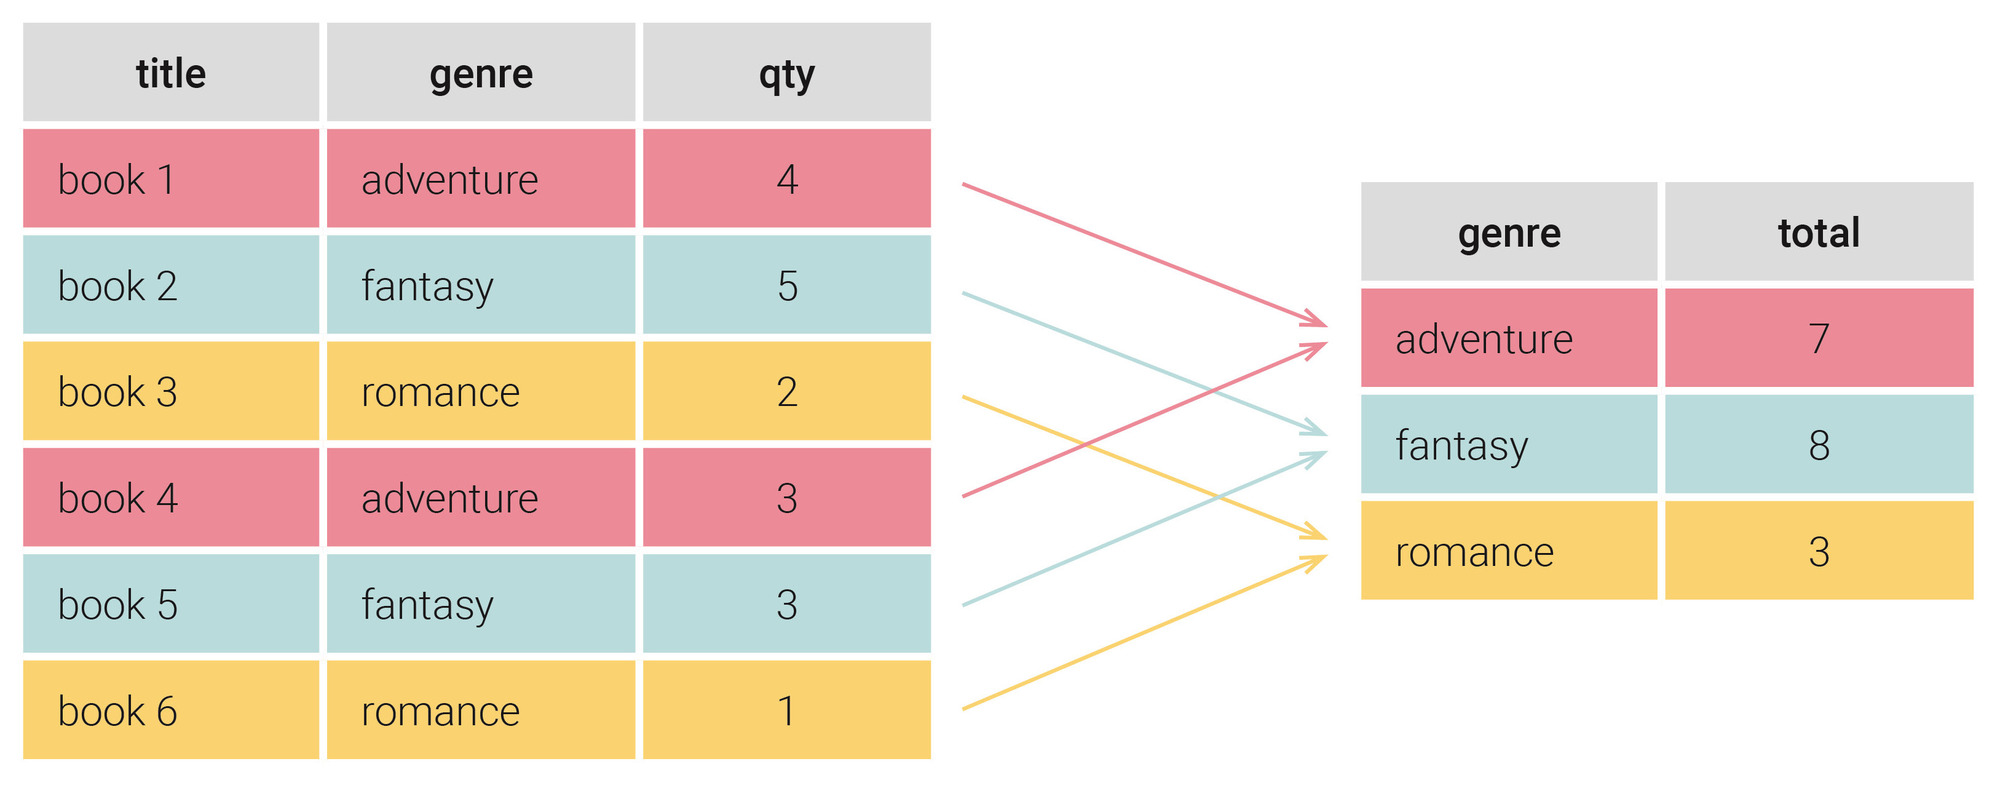


In [70]:
# Basic groupby operation - group by Gender
grouped_by_gender = df.groupby('Gender')
count_by_gender = df.groupby('Gender').count()
print(count_by_gender)

count_size = df.groupby('Gender').size()
print(f"Count size {count_size}")


print("Groups by Gender:")
for name, group in grouped_by_gender: 
    print(f"\n{name}: {len(group)} records")
    print(group[['ID', 'Age']].head(10))

        ID  Age  Height  Weight  Income  Education  Employment  \
Gender                                                           
F       34   34      33      33      33         34          34   
M       36   36      34      35      36         36          36   

        Health Condition  Score  Age_Group  
Gender                                      
F                     33     34         34  
M                     33     36         36  
Count size Gender
F    34
M    36
dtype: int64
Groups by Gender:

F: 34 records
    ID  Age
1    2   32
3    4   28
7    8   33
9   10   27
11  12   35
13  14   24
15  16   31
17  18   26
19  20   30
21  22   23

M: 36 records
    ID  Age
0    1   25
2    3   45
4    5   38
5    6   38
6    7   50
8    9   41
10  11   29
12  13   48
14  15   39
16  17   42


### 3. Single Aggregate Measures

After grouping data, you can apply aggregate functions to compute summary statistics for each group. Common aggregate functions include `mean()`, `sum()`, `count()`, `min()`, `max()`, `std()`, etc.

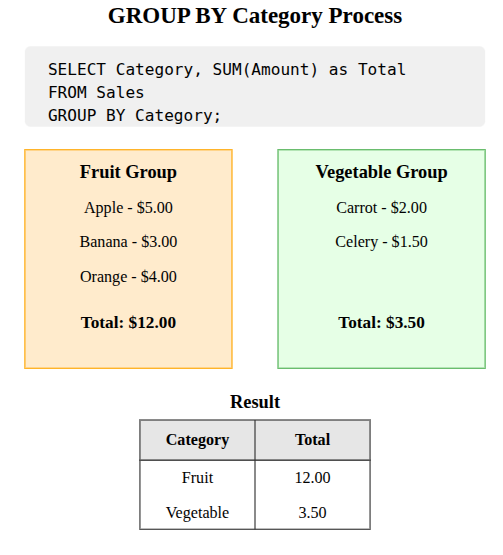

In [55]:
# Single aggregate: mean age by gender
mean_age_by_gender = df.groupby('Gender')['Age'].mean()
print("\nMean age by gender:")
mean_age_by_gender


Mean age by gender:


Gender
F    29.264706
M    40.055556
Name: Age, dtype: float64

In [56]:
# Sum of income by gender
total_income_by_gender = df.groupby('Gender')['Income'].mean()
print("\nTotal income by gender:")
total_income_by_gender


Total income by gender:


Gender
F    39151.515152
M    77750.000000
Name: Income, dtype: float64

In [57]:
# Count of records by gender
count_by_gender = df.groupby('Gender')['ID'].count()
print("\nCount by gender:")
count_by_gender


Count by gender:


Gender
F    34
M    36
Name: ID, dtype: int64

### 4. Multiple Aggregate Measures

You can apply multiple aggregate functions to grouped data using the `agg()` method. This allows you to compute several statistics at once for each group.

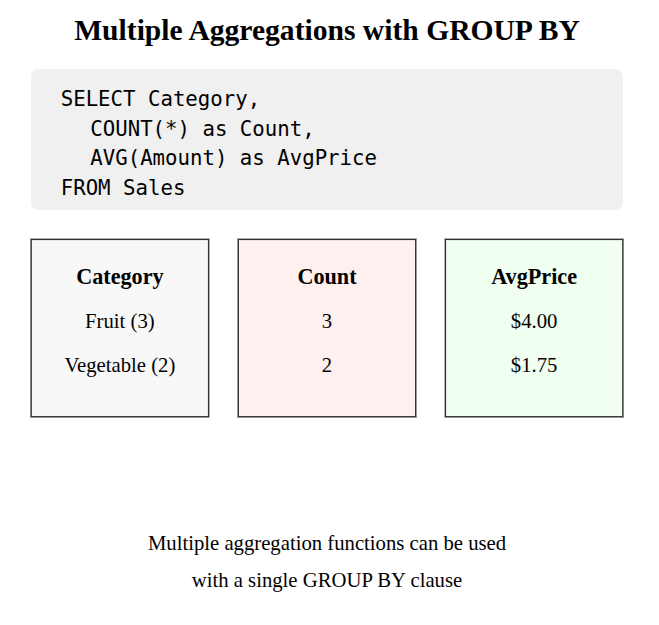


In [ ]:
# Multiple aggregates: mean, min, max for Age and Income by Gender
multi_agg = df.groupby('Gender').agg({
    'Age': ['mean', 'min', 'max'],
    'Income': ['mean', 'sum']
})
print("Multiple aggregates by gender:")
multi_agg



>> Multiple aggregates by gender:


Age                Income           
             mean min max          mean        sum
Gender                                            
F       29.264706  21  50  39151.515152  1292000.0
M       40.055556  22  51  77750.000000  2799000.0

In [59]:
# Using agg with a list for all numeric columns
numeric_agg = df.groupby('Gender')[['Age', 'Weight', 'Income', 'Score']].agg(['mean', 'std', 'count'])

print("\n\n>> Aggregates for all numeric columns by gender:")
numeric_agg[['Age', 'Weight', 'Income']]



>> Aggregates for all numeric columns by gender:


Age                     Weight                         Income  \
             mean       std count       mean        std count          mean   
Gender                                                                        
F       29.264706  6.292414    34  73.393939  87.972275    33  39151.515152   
M       40.055556  7.352140    36  83.800000  18.408438    35  77750.000000   

                           
                std count  
Gender                     
F       7137.581927    33  
M       8881.360900    36

### 5. Grouping by Multiple Columns

You can group data by multiple columns to create more detailed aggregations. This creates a hierarchical grouping where data is first grouped by the first column, then by the second within each group of the first, and so on.


In [60]:
# First, create an age category column for demonstration
def categorize_age(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle'
    else:
        return 'Senior'

df['Age_Group'] = df['Age'].apply(categorize_age)

# Group by multiple columns: Gender and Age_Group
multi_group = df.groupby(['Gender', 'Age_Group'])['Income'].mean()
print("Mean income by Gender and Age Group:")
multi_group

Mean income by Gender and Age Group:


Gender  Age_Group
F       Middle       44750.000000
        Senior       43000.000000
        Young        35600.000000
M       Middle       78793.103448
        Senior       91333.333333
        Young        60000.000000
Name: Income, dtype: float64

In [61]:
# Multiple aggregates on multiple groups
multi_group_agg = df.groupby(['Gender', 'Age_Group']).agg({
    'Income': ['mean', 'count'],
    'Age': 'mean'
})
print("\nMultiple aggregates by Gender and Age Group:")
multi_group_agg


Multiple aggregates by Gender and Age Group:


Income              Age
                          mean count       mean
Gender Age_Group                               
F      Middle     44750.000000    12  33.769231
       Senior     43000.000000     1  50.000000
       Young      35600.000000    20  25.300000
M      Middle     78793.103448    29  40.896552
       Senior     91333.333333     3  50.333333
       Young      60000.000000     4  26.250000

### 6. Dataset Preparation for Merging

Before merging DataFrames, it's important to ensure that the datasets are properly prepared. This includes:

- Ensuring common columns have the same data types
- Handling missing values appropriately
- Checking for duplicate keys
- Understanding the relationship between datasets


In [62]:
# Check data types of common columns
print("Person info dtypes:")
print(df.dtypes)
print("\nDepartment info dtypes:")
print(dept_df.dtypes)

# Ensure ID columns are the same type
df['ID'] = df['ID'].astype(int)
dept_df['ID'] = dept_df['ID'].astype(int)

# Check for missing values
print("\nMissing values in person_info:")
print(df.isnull().sum())
print("\nMissing values in department_info:")
print(dept_df.isnull().sum())

# Check for duplicates in key columns
print(f"\nDuplicate IDs in person_info: {df['ID'].duplicated().sum()}")
print(f"Duplicate IDs in department_info: {dept_df['ID'].duplicated().sum()}")

# Preview the datasets before merging
print("\nPerson info preview:")
print(df[['ID', 'Age', 'Gender']].head())
print("\nDepartment info preview:")
print(dept_df.head())


Person info dtypes:
ID                    int64
Age                   int64
Gender                  str
Height                  str
Weight              float64
Income              float64
Education               str
Employment              str
Health Condition        str
Score               float64
Age_Group               str
dtype: object

Department info dtypes:
ID            int64
Department      str
Salary        int64
dtype: object

Missing values in person_info:
ID                  0
Age                 0
Gender              1
Height              4
Weight              3
Income              2
Education           1
Employment          1
Health Condition    5
Score               1
Age_Group           0
dtype: int64

Missing values in department_info:
ID            0
Department    0
Salary        0
dtype: int64

Duplicate IDs in person_info: 0
Duplicate IDs in department_info: 0

Person info preview:
   ID  Age Gender
0   1   25      M
1   2   32      F
2   3   45      M
3   4   28  

### 7. Merging DataFrames

Merging DataFrames combines data from multiple sources based on common columns or indices. The main types of merges are:

- **Inner Join**: Only matching rows from both DataFrames
- **Left Join**: All rows from left DataFrame, matching rows from right
- **Right Join**: All rows from right DataFrame, matching rows from left  
- **Outer Join**: All rows from both DataFrames

The `merge()` function is used: `pd.merge(left_df, right_df, on='key_column', how='inner')`


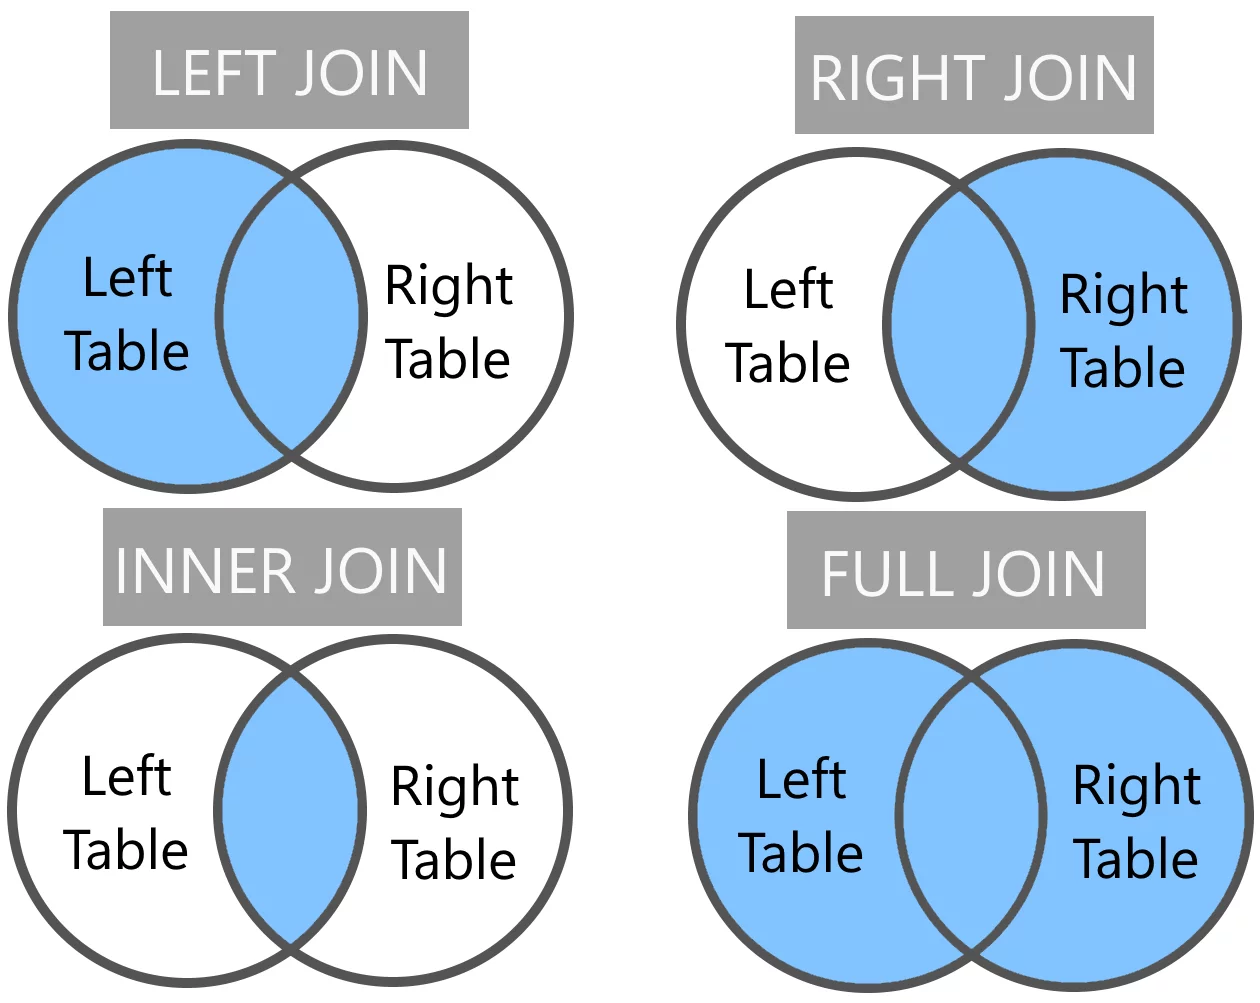
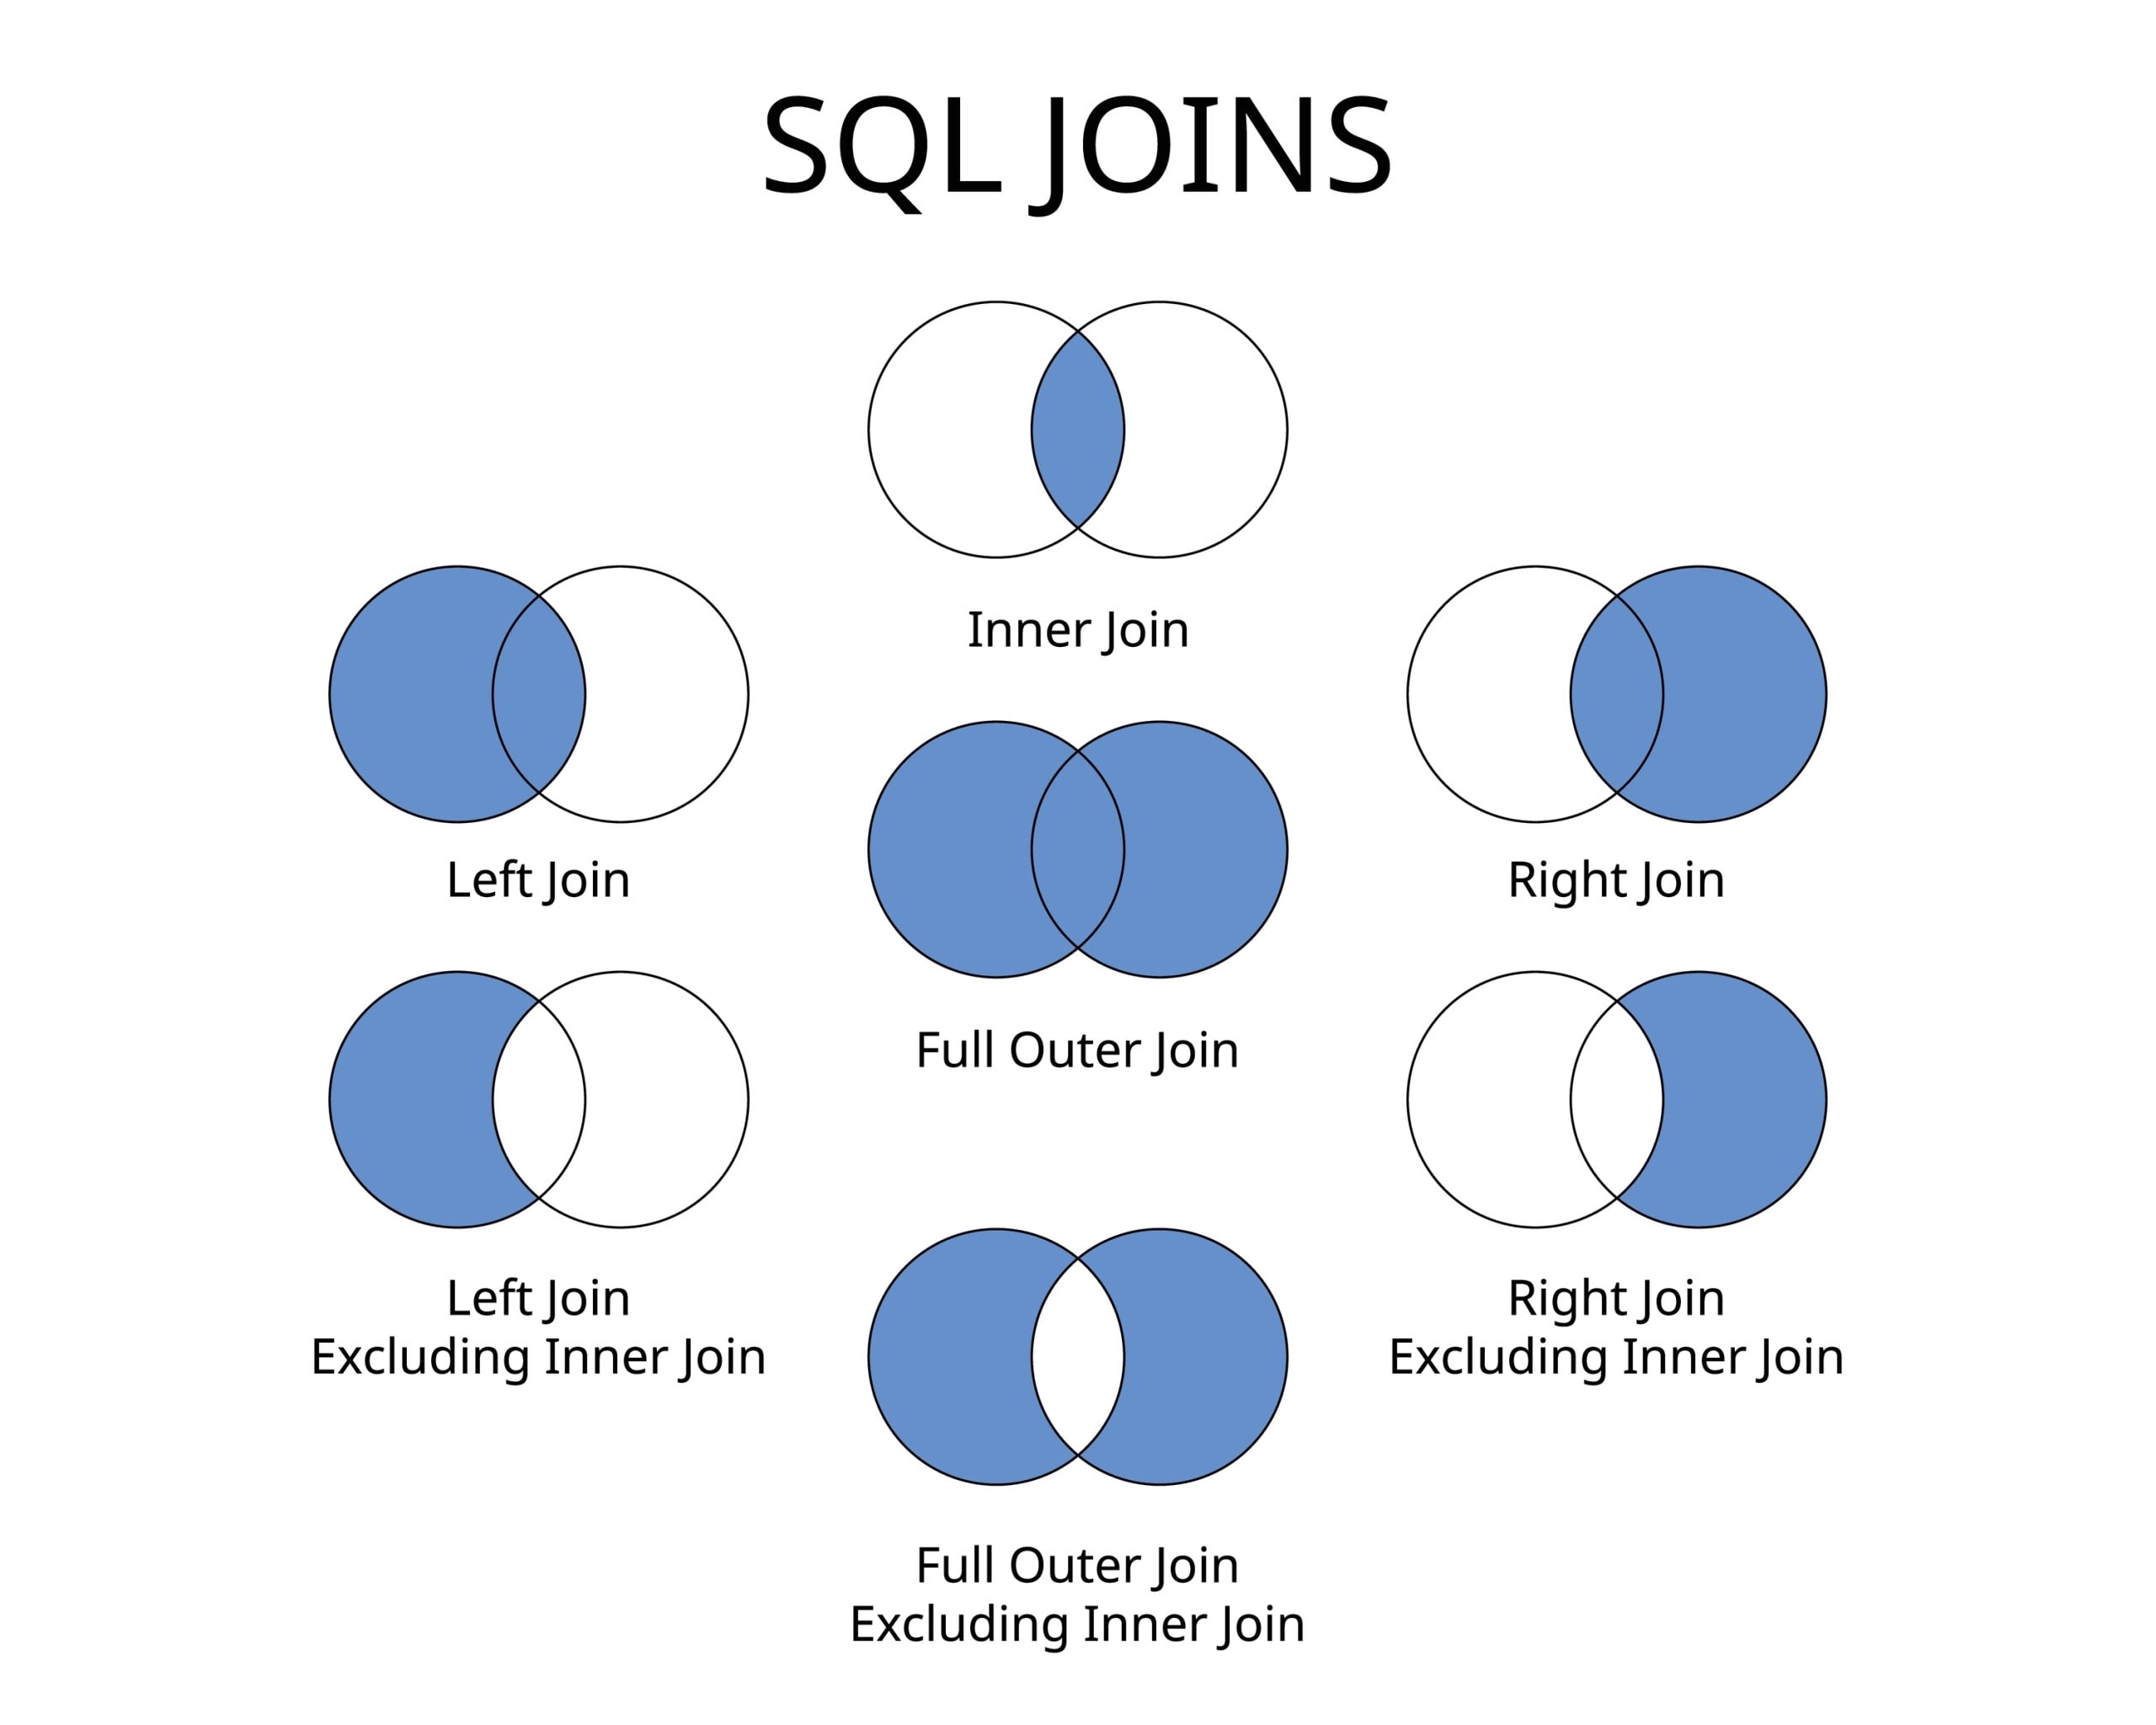

In [71]:
df['ID'].shape

(71,)

In [64]:
dept_df['ID'].shape

(10,)

#### 7.1 Inner Join

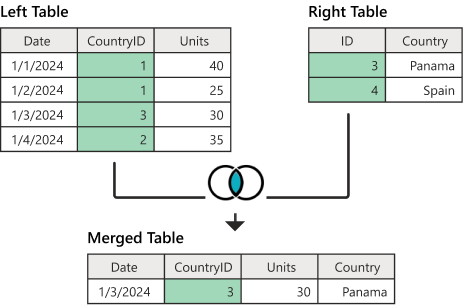

In [65]:
# Inner join - only matching IDs
inner_merge = pd.merge(df, dept_df, on='ID', how='inner')
print("Inner merge result:")
print(inner_merge[['ID', 'Age', 'Gender', 'Department', 'Salary']])
print(f"Shape: {inner_merge.shape}")

Inner merge result:
   ID  Age Gender   Department  Salary
0   1   25      M  Engineering   70000
1   2   32      F    Marketing   50000
2   3   45      M        Sales   60000
3   4   28      F           HR   45000
4   5   38      M  Engineering   75000
5   6   38      M    Marketing   52000
6   7   50      M        Sales   58000
7   8   33      F           HR   47000
8   9   41      M  Engineering   72000
9  10   27      F    Marketing   51000
Shape: (10, 13)


#### 7.2 Left Join

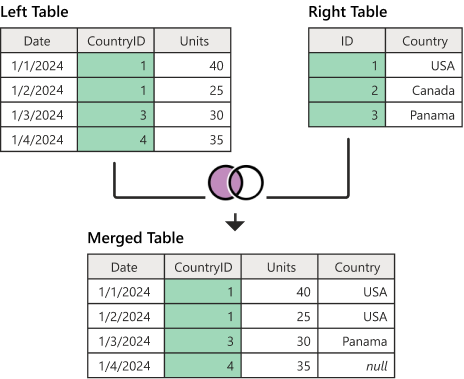

In [66]:
# Left join - all from person_info, matching from department_info
left_merge = pd.merge(df, dept_df, on='ID', how='left')
print("\nLeft merge result:")
print(left_merge[['ID', 'Age', 'Gender', 'Department', 'Salary']].head())
print(f"Shape: {left_merge.shape}")


Left merge result:
   ID  Age Gender   Department   Salary
0   1   25      M  Engineering  70000.0
1   2   32      F    Marketing  50000.0
2   3   45      M        Sales  60000.0
3   4   28      F           HR  45000.0
4   5   38      M  Engineering  75000.0
Shape: (71, 13)


#### 7.3 Right Join

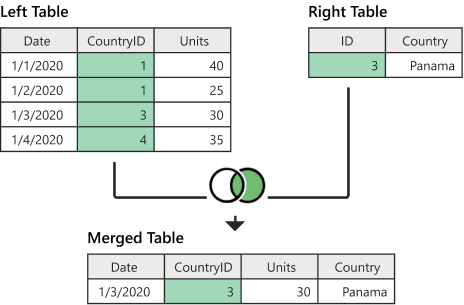

In [67]:
# Right join - all from department_info, matching from person_info
right_merge = pd.merge(df, dept_df, on='ID', how='right')
print("\nRight merge result:")
print(right_merge[['ID', 'Age', 'Gender', 'Department', 'Salary']].head())
print(f"Shape: {right_merge.shape}")


Right merge result:
   ID  Age Gender   Department  Salary
0   1   25      M  Engineering   70000
1   2   32      F    Marketing   50000
2   3   45      M        Sales   60000
3   4   28      F           HR   45000
4   5   38      M  Engineering   75000
Shape: (10, 13)


#### 7.4 Outer Join

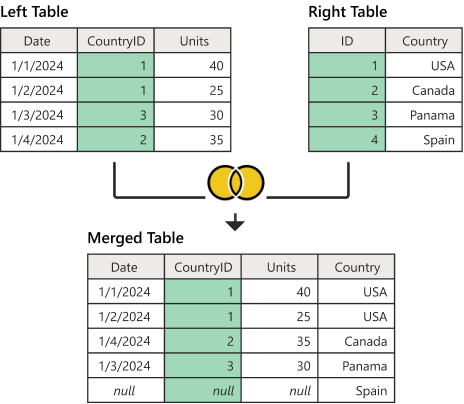

In [68]:
# Outer join - all from both DataFrames
outer_merge = pd.merge(df, dept_df, on='ID', how='outer')
print("\nOuter merge result:")
print(outer_merge[['ID', 'Age', 'Gender', 'Department', 'Salary']].head())
print(f"Shape: {outer_merge.shape}")


Outer merge result:
   ID  Age Gender   Department   Salary
0   1   25      M  Engineering  70000.0
1   2   32      F    Marketing  50000.0
2   3   45      M        Sales  60000.0
3   4   28      F           HR  45000.0
4   5   38      M  Engineering  75000.0
Shape: (71, 13)


### Practice Questions

#### With Hints
Try these easy exercises to practice what you've learned. Each question includes a slight hint.

1. **Group the person_info DataFrame by 'Gender' and calculate the average age.**  
   *Hint: Use `df.groupby('Gender')['Age'].mean()`.*

2. **Group by 'Gender' and get multiple aggregates (mean and max) for 'Income'.**  
   *Hint: Use `df.groupby('Gender')['Income'].agg(['mean', 'max'])`.*

3. **Group by both 'Gender' and 'Age_Group' and count the number of records.**  
   *Hint: Use `df.groupby(['Gender', 'Age_Group'])['ID'].count()`.*

4. **Perform an inner merge between person_info and department_info on 'ID'.**  
   *Hint: Use `pd.merge(df, dept_df, on='ID', how='inner')`.*

5. **Perform a left merge and check the shape of the resulting DataFrame.**  
   *Hint: Use `pd.merge(df, dept_df, on='ID', how='left')` and then `.shape`.*

6. **Group the merged DataFrame by 'Department' and calculate average salary.**  
   *Hint: First merge, then `merged_df.groupby('Department')['Salary'].mean()`.*

7. **Find the maximum age in each age group using groupby.**  
   *Hint: Use `df.groupby('Age_Group')['Age'].max()`.*

8. **Perform an outer merge and count total rows.**  
   *Hint: Use `pd.merge(df, dept_df, on='ID', how='outer')` and check length.*

#### Without Hints
Now try similar questions without hints for real practice! 

1. Calculate the total income by gender using groupby.

2. Get the count of people in each department after merging.

3. Group by age group and find the minimum and maximum income.

4. Perform a right merge between the DataFrames.

5. Calculate the average age by department from the merged data.

6. Group by gender and age group, then get the sum of incomes.

7. Find the number of people in each gender and age group combination.

8. Perform an inner merge and calculate the average salary by gender.

Try writing the code for each question in a new cell below. You can check your answers by running the cells!
